In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_support_tickets.csv to customer_support_tickets.csv
Saving customers.csv to customers.csv
Saving product_usage.csv to product_usage.csv


In [ ]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('customer_support_tickets.csv')

# View the first few rows of the data
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other              Jira       22-03-2021  Technical issue   
1          Female        Confluence       22-05-2021  Technical issue   
2           Other            Trello       14-07-2020  Technical issue   
3          Female              Loom       13-11-2020  Billing inquiry   
4          Female         Bitbucket       04-02-2020  Billing inquiry   

    Ticket Subject              Ticket Status  \
0    Product setup  Pending Customer 

In [ ]:
# ============================================================
# 1. Import libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")

In [ ]:
usage = pd.read_csv("/content/product_usage.csv", encoding="utf-8-sig")

In [ ]:
# Dataset dimensions
print("Rows and columns:", usage.shape)

# Column types
print("\nColumn types:")
print(usage.dtypes)

# Missing values
print("\nMissing values:")
print(usage.isna().sum())

# Duplicate customer-product-month observations
duplicates = usage.duplicated(
    subset=["Customer ID", "Product", "Month"]
).sum()

print("\nDuplicate customer-product-month rows:", duplicates)

# Summary statistics
usage[["Active Days", "Collaborators"]].describe()

Rows and columns: (42210, 8)

Column types:
Customer ID          object
Product              object
Month                object
Active Days           int64
Sessions              int64
Product Actions       int64
Collaborators         int64
Integrations Used     int64
dtype: object

Missing values:
Customer ID          0
Product              0
Month                0
Active Days          0
Sessions             0
Product Actions      0
Collaborators        0
Integrations Used    0
dtype: int64

Duplicate customer-product-month rows: 0


,Active Days,Collaborators
count,42210.000000,42210.000000
mean,8.724544,11.073134
std,4.955702,3.760565
min,1.000000,2.000000
25%,5.000000,8.000000
50%,8.000000,11.000000
75%,11.000000,14.000000
max,31.000000,23.000000


In [ ]:
# Convert Month from text into a proper date
usage["Month"] = pd.to_datetime(
    usage["Month"],
    format="%Y-%m"
)

# Sort chronologically
usage = usage.sort_values("Month")

print("Date range:")
print(usage["Month"].min(), "to", usage["Month"].max())

Date range:
2023-01-01 00:00:00 to 2023-05-01 00:00:00


In [ ]:
monthly_summary = (
    usage
    .groupby("Month", as_index=False)
    .agg(
        average_active_days=("Active Days", "mean"),
        average_collaborators=("Collaborators", "mean"),
        observations=("Customer ID", "size")
    )
)

monthly_summary

,Month,average_active_days,average_collaborators,observations
0,2023-01-01,8.730633,11.074271,8442
1,2023-02-01,8.764985,11.093224,8442
2,2023-03-01,8.735134,11.067164,8442
3,2023-04-01,8.708244,11.071429,8442
4,2023-05-01,8.683724,11.059583,8442


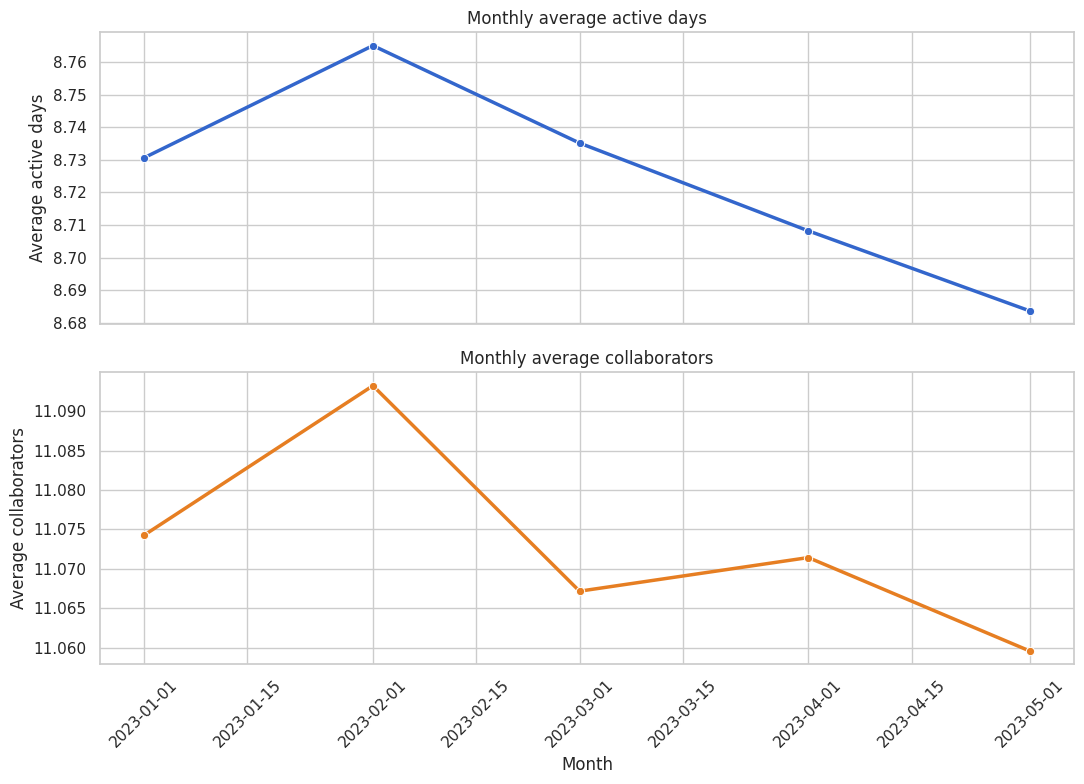

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 8),
    sharex=True
)

# Average active days
sns.lineplot(
    data=monthly_summary,
    x="Month",
    y="average_active_days",
    marker="o",
    linewidth=2.5,
    ax=axes[0],
    color="#3366CC"
)

axes[0].set_title("Monthly average active days")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average active days")

# Average collaborators
sns.lineplot(
    data=monthly_summary,
    x="Month",
    y="average_collaborators",
    marker="o",
    linewidth=2.5,
    ax=axes[1],
    color="#E67E22"
)

axes[1].set_title("Monthly average collaborators")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average collaborators")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

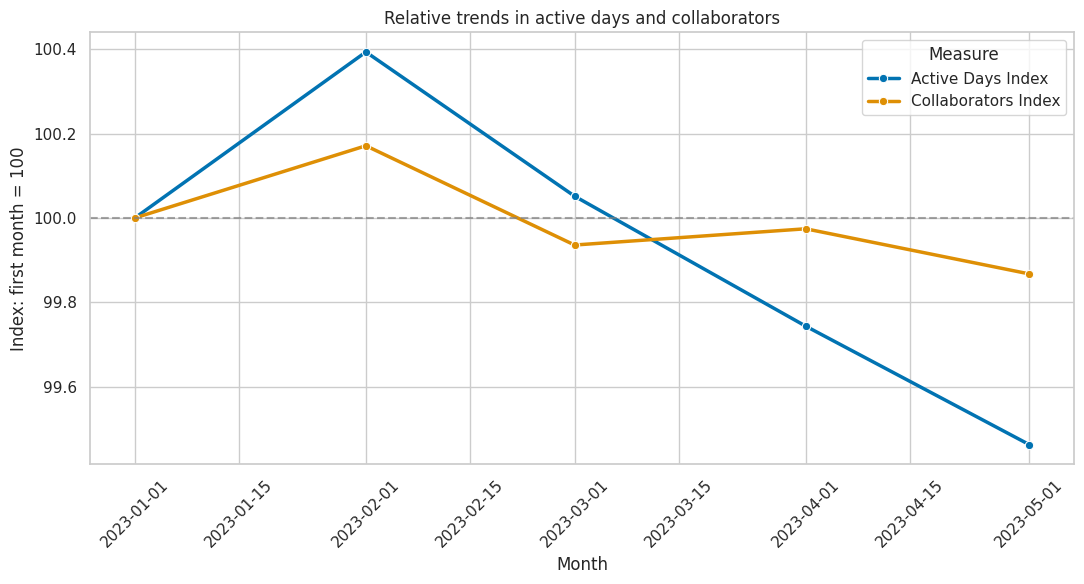

In [ ]:
indexed_summary = monthly_summary.copy()

indexed_summary["Active Days Index"] = (
    indexed_summary["average_active_days"]
    / indexed_summary["average_active_days"].iloc[0]
    * 100
)

indexed_summary["Collaborators Index"] = (
    indexed_summary["average_collaborators"]
    / indexed_summary["average_collaborators"].iloc[0]
    * 100
)

indexed_long = indexed_summary.melt(
    id_vars="Month",
    value_vars=["Active Days Index", "Collaborators Index"],
    var_name="Measure",
    value_name="Index"
)

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=indexed_long,
    x="Month",
    y="Index",
    hue="Measure",
    marker="o",
    linewidth=2.5
)

plt.axhline(
    100,
    color="grey",
    linestyle="--",
    alpha=0.7,
    label="January baseline"
)

plt.title("Relative trends in active days and collaborators")
plt.xlabel("Month")
plt.ylabel("Index: first month = 100")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

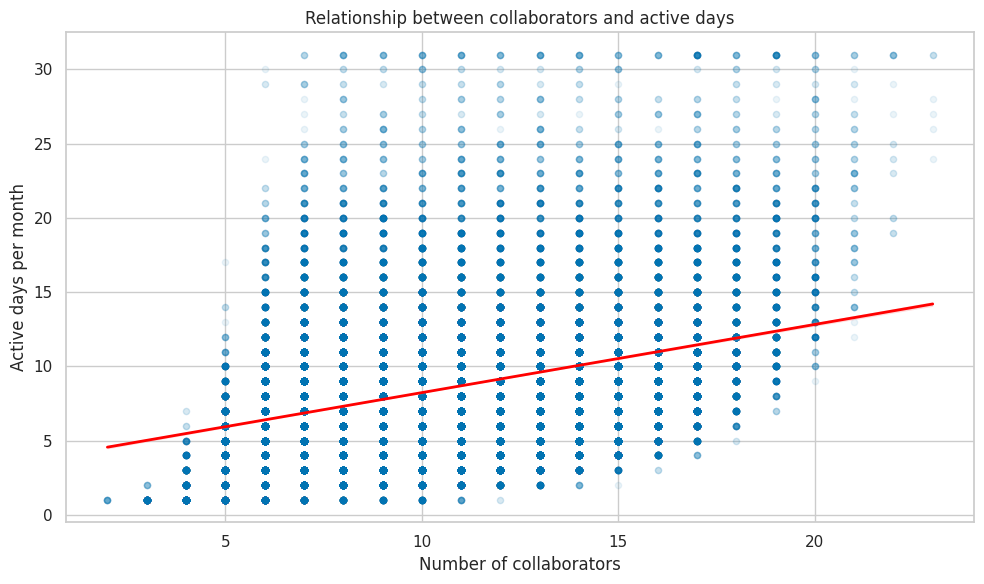

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=usage,
    x="Collaborators",
    y="Active Days",
    scatter_kws={
        "alpha": 0.08,
        "s": 20
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

plt.title("Relationship between collaborators and active days")
plt.xlabel("Number of collaborators")
plt.ylabel("Active days per month")
plt.tight_layout()
plt.show()

In [ ]:
collaborator_summary = (
    usage
    .groupby("Collaborators", as_index=False)
    .agg(
        average_active_days=("Active Days", "mean"),
        median_active_days=("Active Days", "median"),
        observations=("Active Days", "size")
    )
)

collaborator_summary

,Collaborators,average_active_days,median_active_days,observations
0,2,1.000000,1.0,11
1,3,1.064815,1.0,108
2,4,2.130864,2.0,405
3,5,4.676651,4.0,1469
4,6,6.830139,6.0,3026
5,7,7.981965,7.0,3715
6,8,8.099194,7.0,3720
7,9,8.252013,7.0,3726
8,10,8.339227,7.0,3676
9,11,8.431334,7.0,3568


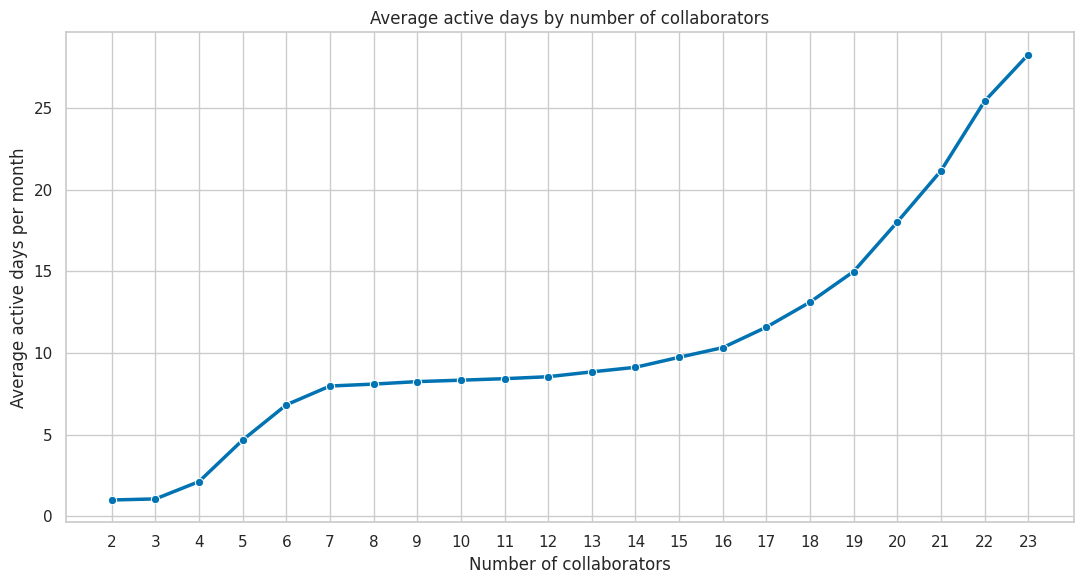

In [ ]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=collaborator_summary,
    x="Collaborators",
    y="average_active_days",
    marker="o",
    linewidth=2.5
)

plt.title("Average active days by number of collaborators")
plt.xlabel("Number of collaborators")
plt.ylabel("Average active days per month")
plt.xticks(collaborator_summary["Collaborators"])
plt.tight_layout()
plt.show()

In [ ]:
pearson_correlation = usage[
    ["Active Days", "Collaborators"]
].corr(method="pearson").iloc[0, 1]

spearman_correlation = usage[
    ["Active Days", "Collaborators"]
].corr(method="spearman").iloc[0, 1]

print(f"Pearson correlation:  {pearson_correlation:.3f}")
print(f"Spearman correlation: {spearman_correlation:.3f}")

Pearson correlation:  0.348
Spearman correlation: 0.344


In [ ]:
product_summary = (
    usage
    .groupby(["Month", "Product"], as_index=False)
    .agg(
        average_active_days=("Active Days", "mean"),
        average_collaborators=("Collaborators", "mean"),
        observations=("Customer ID", "size")
    )
)

product_summary.head()

,Month,Product,average_active_days,average_collaborators,observations
0,2023-01-01,Bitbucket,9.279245,11.389308,1590
1,2023-01-01,Confluence,8.650411,11.176986,1825
2,2023-01-01,Jira,10.029792,11.423834,1779
3,2023-01-01,Loom,6.757222,10.351567,1627
4,2023-01-01,Trello,8.837754,10.991363,1621


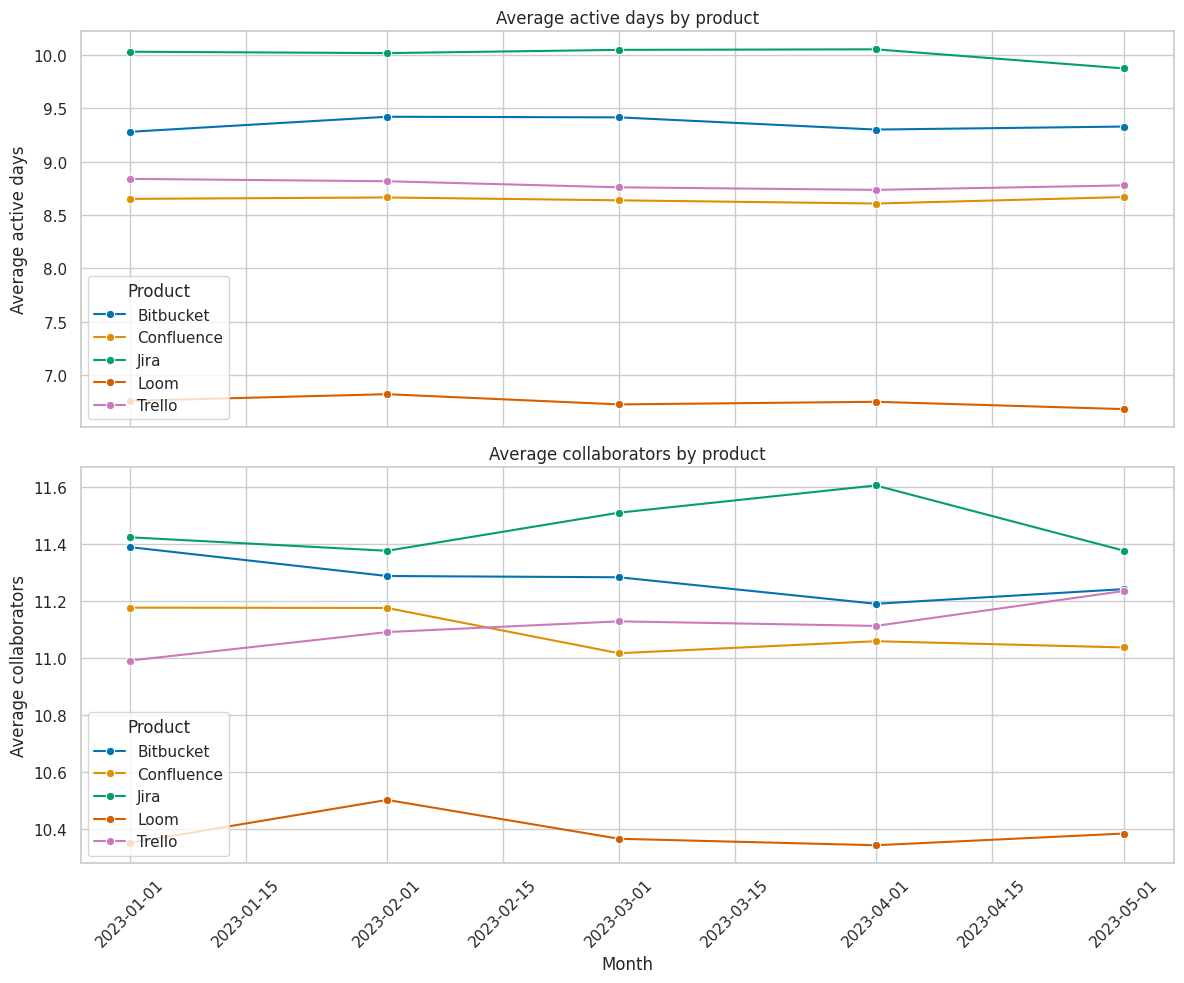

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 10),
    sharex=True
)

sns.lineplot(
    data=product_summary,
    x="Month",
    y="average_active_days",
    hue="Product",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Average active days by product")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average active days")

sns.lineplot(
    data=product_summary,
    x="Month",
    y="average_collaborators",
    hue="Product",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Average collaborators by product")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average collaborators")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
product_correlations = (
    usage
    .groupby("Product")
    .apply(
        lambda group: pd.Series({
            "observations": len(group),
            "pearson_correlation": group[
                "Active Days"
            ].corr(group["Collaborators"], method="pearson"),
            "spearman_correlation": group[
                "Active Days"
            ].corr(group["Collaborators"], method="spearman")
        }),
        include_groups=False
    )
    .reset_index()
)

product_correlations.round(3)

,Product,observations,pearson_correlation,spearman_correlation
0,Bitbucket,7950.0,0.321,0.320
1,Confluence,9125.0,0.357,0.344
2,Jira,8895.0,0.329,0.315
3,Loom,8135.0,0.378,0.378
4,Trello,8105.0,0.317,0.319


In [21]:
# Engagement intensity
usage["Actions per Active Day"] = (
    usage["Product Actions"] /
    usage["Active Days"]
)

# Sessions per active day
usage["Sessions per Active Day"] = (
    usage["Sessions"] /
    usage["Active Days"]
)

# Actions per session
usage["Actions per Session"] = (
    usage["Product Actions"] /
    usage["Sessions"]
)

# Collaboration intensity
usage["Actions per Collaborator"] = (
    usage["Product Actions"] /
    usage["Collaborators"]
)

In [22]:
usage.groupby("Product")[
    [
        "Actions per Active Day",
        "Sessions per Active Day",
        "Actions per Session",
        "Actions per Collaborator"
    ]
].median().round(2)

,Actions per Active Day,Sessions per Active Day,Actions per Session,Actions per Collaborator
Product,,,,
Bitbucket,11.50,2.0,5.74,8.40
Confluence,11.50,2.0,5.78,7.92
Jira,11.47,2.0,5.72,8.95
Loom,11.50,2.0,5.78,6.56
Trello,11.29,2.0,5.67,7.94


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

customer_behaviour = (
    usage
    .groupby("Customer ID")
    .agg(
        active_days=("Active Days", "mean"),
        sessions=("Sessions", "mean"),
        actions=("Product Actions", "mean"),
        collaborators=("Collaborators", "mean"),
        integrations=("Integrations Used", "mean")
    )
    .dropna()
)

features = [
    "active_days",
    "sessions",
    "actions",
    "collaborators",
    "integrations"
]

scaled_data = StandardScaler().fit_transform(
    customer_behaviour[features]
)

model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

customer_behaviour["segment"] = model.fit_predict(scaled_data)